In [97]:
# MTP Co-Intelligent Finance: AI-driven transformations in Capital Market, Stock & Risk Prediction
# By - M24DE3035 - Geetika Vijay
# Python Implementation Results Analysis for Linear Regressions Algorithms

In [98]:
# ************** Stock Prediction with Linear, Ridge, and Lasso Regression # ************** #
# **************  Required packages # ************** #
# **************  pip install yfinance pandas numpy scikit-learn matplotlib seaborn tensorflow # ************** #

import os
import random
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
from datetime import datetime
import matplotlib.dates as mdates

In [99]:
# ************** Reproducibility # ************** #
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

In [100]:
# ************** 1. Download data # ************** #
def download_data(ticker='AAPL', start='2015-01-01', end=None):
    df = yf.download(ticker, start=start, end=end, progress=False)
    # Flatten MultiIndex columns if they exist (common with yfinance for single ticker)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1) # Drops the ticker level, keeping the financial metric
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna() # Ensure all relevant columns are present
    return df

df = download_data('AAPL', start='2015-01-01')

/tmp/ipython-input-521263370.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


In [101]:
# ************** Basic feature engineering # ************** #
df_feat = df.copy()
df_feat['Return'] = df_feat['Close'].pct_change()
df_feat['LogReturn'] = np.log(df_feat['Close']).diff()
# Simple moving averages
df_feat['SMA_20'] = df_feat['Close'].rolling(window=20).mean()
df_feat['SMA_50'] = df_feat['Close'].rolling(window=50).mean()
# Exponential moving average
df_feat['EMA_20'] = df_feat['Close'].ewm(span=20, adjust=False).mean()
# Volatility (rolling std of returns)
df_feat['Vol_20'] = df_feat['Return'].rolling(window=20).std()
# MACD (12-26) and signal (9)
ema12 = df_feat['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_feat['Close'].ewm(span=26, adjust=False).mean()
df_feat['MACD'] = ema12 - ema26
df_feat['MACD_Signal'] = df_feat['MACD'].ewm(span=9, adjust=False).mean()
# Drop initial NaNs
df_feat = df_feat.dropna()

# Create output folder for figures
FIG_DIR = 'eda_figures'
os.makedirs(FIG_DIR, exist_ok=True)

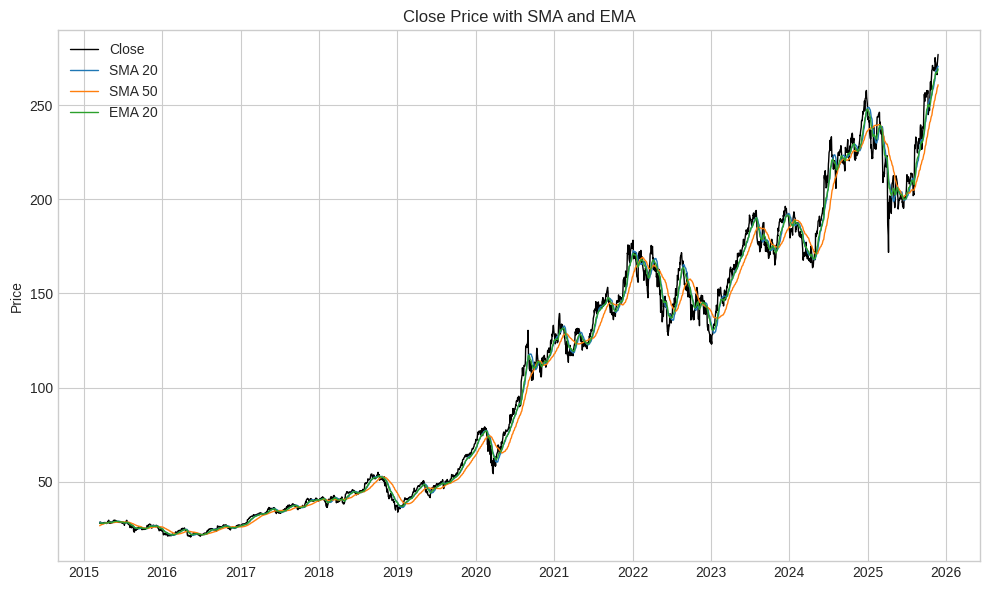

In [102]:
# ************** 1. Time series plot: Close price with SMA/EMA # ************** #
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(df_feat.index, df_feat['Close'], label='Close', color='black', linewidth=1)
ax.plot(df_feat.index, df_feat['SMA_20'], label='SMA 20', color='#1f77b4', linewidth=1)
ax.plot(df_feat.index, df_feat['SMA_50'], label='SMA 50', color='#ff7f0e', linewidth=1)
ax.plot(df_feat.index, df_feat['EMA_20'], label='EMA 20', color='#2ca02c', linewidth=1)
ax.set_title('Close Price with SMA and EMA')
ax.set_ylabel('Price')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'price_sma_ema.png'), dpi=200)
plt.show()

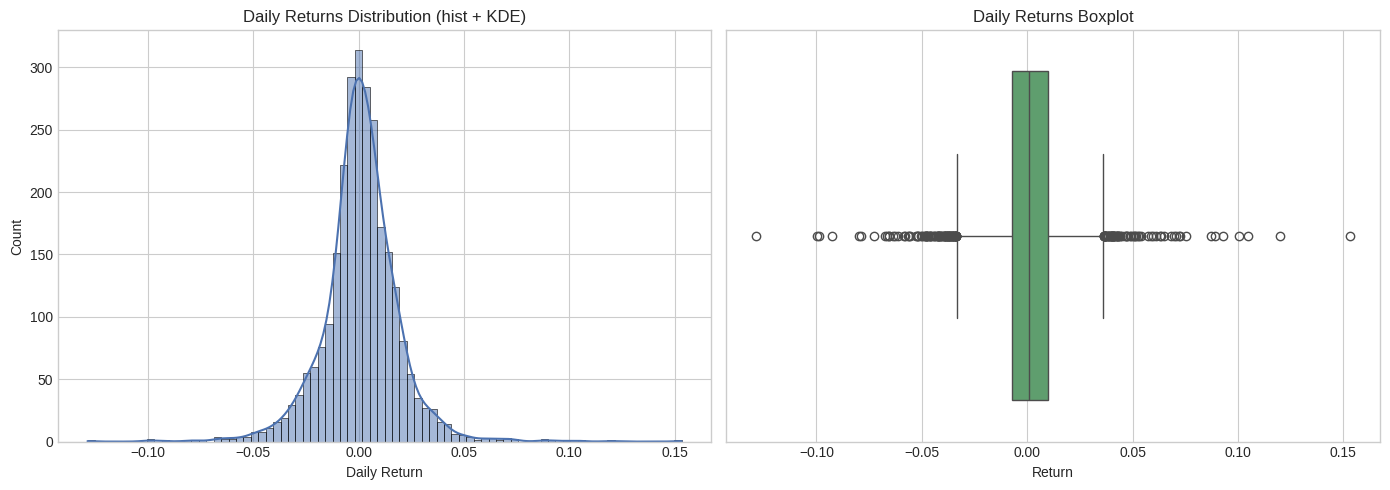

In [103]:
# ************** 2. Returns distribution: histogram + KDE # ************** #
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(df_feat['Return'].dropna(), bins=80, kde=True, ax=ax[0], color='#4C72B0')
ax[0].set_title('Daily Returns Distribution (hist + KDE)')
ax[0].set_xlabel('Daily Return')
sns.boxplot(x=df_feat['Return'].dropna(), ax=ax[1], color='#55A868')
ax[1].set_title('Daily Returns Boxplot')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'returns_dist_box.png'), dpi=200)
plt.show()

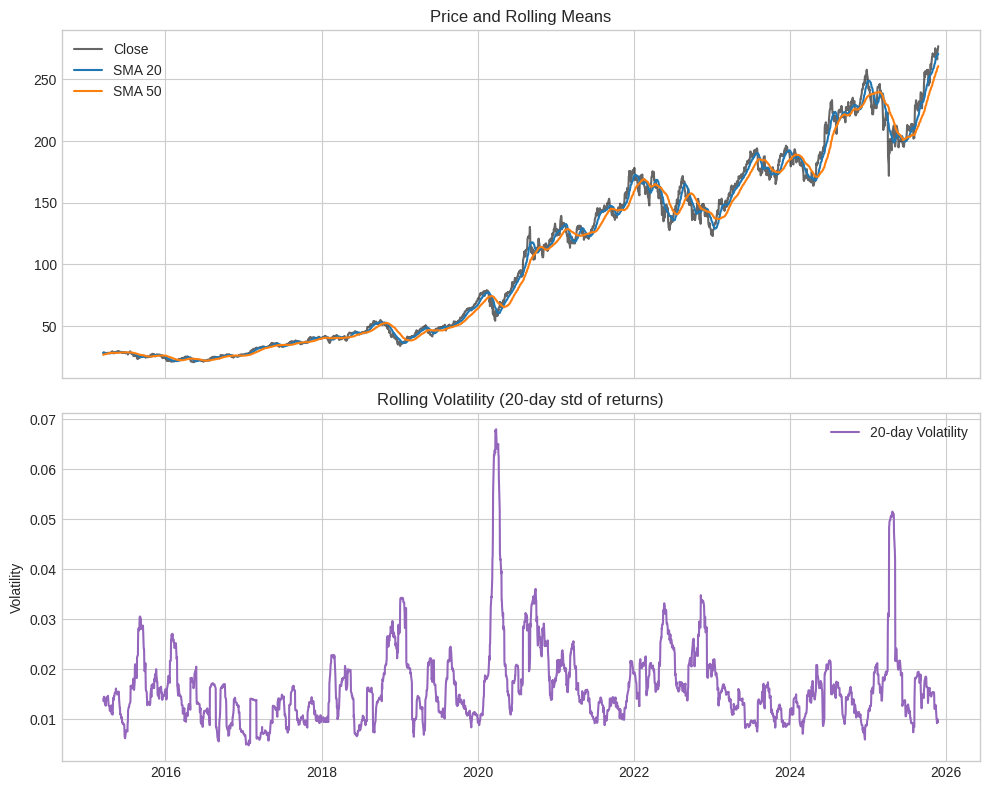

In [104]:
# ************** 3. Rolling statistics: rolling mean and volatility # ************** #
fig, ax = plt.subplots(2,1, figsize=(10,8), sharex=True)
ax[0].plot(df_feat.index, df_feat['Close'], label='Close', color='black', alpha=0.6)
ax[0].plot(df_feat.index, df_feat['SMA_20'], label='SMA 20', color='#1f77b4')
ax[0].plot(df_feat.index, df_feat['SMA_50'], label='SMA 50', color='#ff7f0e')
ax[0].set_title('Price and Rolling Means')
ax[0].legend()
ax[1].plot(df_feat.index, df_feat['Vol_20'], label='20-day Volatility', color='#9467bd')
ax[1].set_title('Rolling Volatility (20-day std of returns)')
ax[1].set_ylabel('Volatility')
ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'rolling_stats.png'), dpi=200)
plt.show()

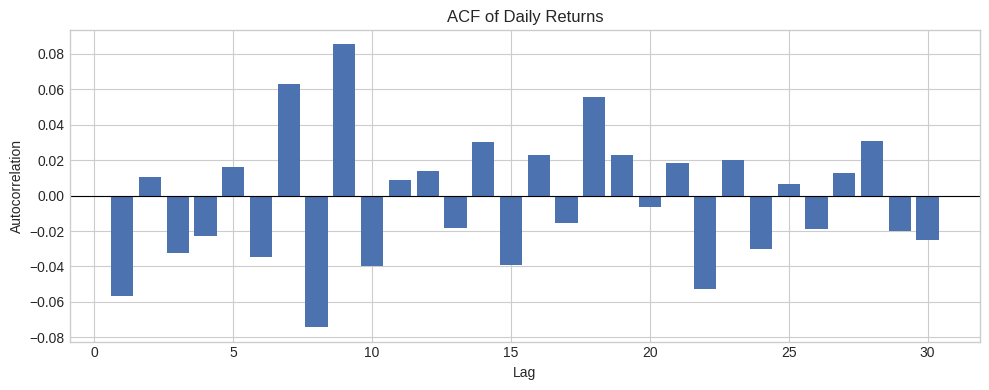

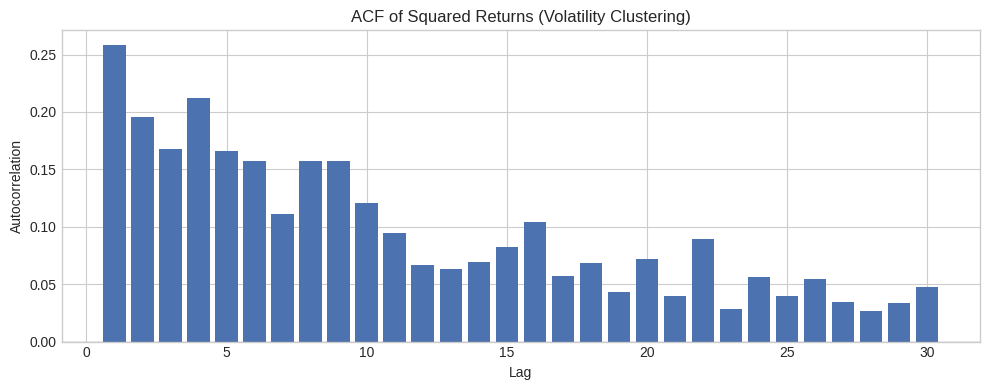

In [105]:
# ************** 4. Autocorrelation (ACF) for returns and squared returns (up to lag 30) # ************** #
def plot_autocorr(series, lags=30, title='Autocorrelation', fname=None):
    acfs = [series.autocorr(lag=i) for i in range(1, lags+1)]
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(1, lags+1), acfs, color='#4C72B0')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(title)
    plt.tight_layout()
    if fname:
        fig.savefig(os.path.join(FIG_DIR, fname), dpi=200)
    plt.show()

plot_autocorr(df_feat['Return'].dropna(), lags=30, title='ACF of Daily Returns', fname='acf_returns.png')
plot_autocorr(df_feat['Return'].dropna()**2, lags=30, title='ACF of Squared Returns (Volatility Clustering)', fname='acf_squared_returns.png')

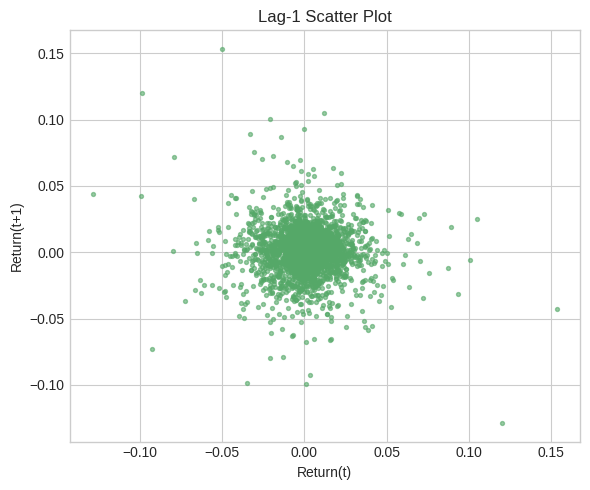

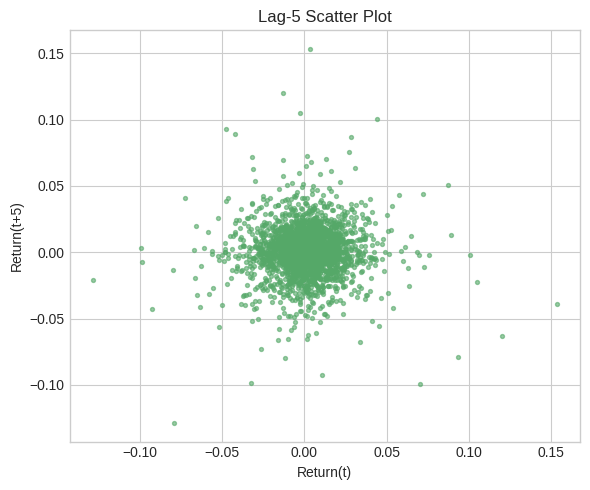

In [106]:
# ************** 5. Lag scatter plots (lag-1, lag-5) to visualize linear dependence # ************** #
def lag_scatter(series, lag=1, fname=None):
    s = series.dropna()
    x = s[:-lag]
    y = s[lag:]
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(x, y, s=8, alpha=0.6, color='#55A868')
    ax.set_xlabel(f'Return(t)')
    ax.set_ylabel(f'Return(t+{lag})')
    ax.set_title(f'Lag-{lag} Scatter Plot')
    plt.tight_layout()
    if fname:
        fig.savefig(os.path.join(FIG_DIR, fname), dpi=200)
    plt.show()

lag_scatter(df_feat['Return'], lag=1, fname='lag1_scatter.png')
lag_scatter(df_feat['Return'], lag=5, fname='lag5_scatter.png')

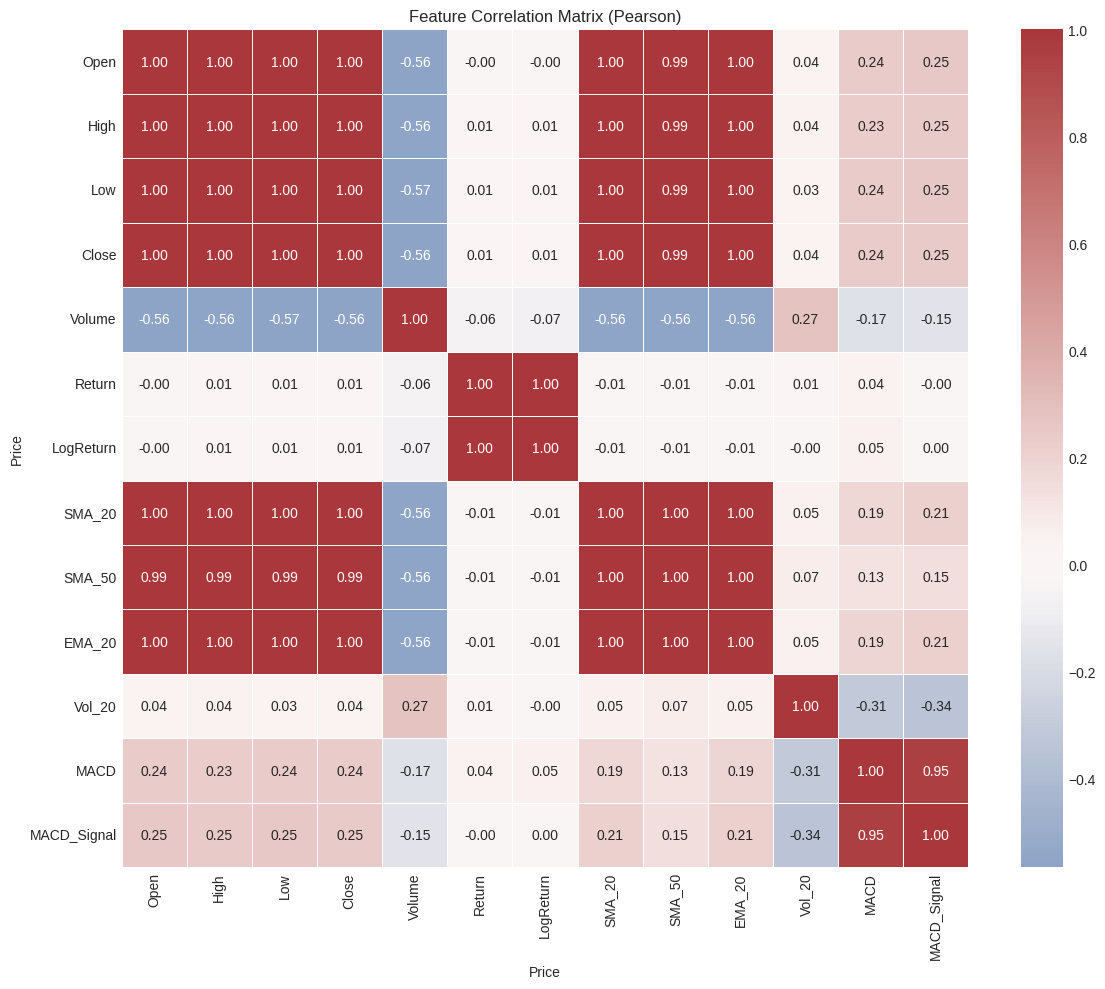

In [107]:
# **************  6. Pairwise correlation matrix and heatmap # ************** #
# Build a features DataFrame for correlation
corr_features = df_feat[['Open','High','Low','Close','Volume','Return','LogReturn','SMA_20','SMA_50','EMA_20','Vol_20','MACD','MACD_Signal']].copy()
corr_matrix = corr_features.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='vlag', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix (Pearson)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'correlation_heatmap.png'), dpi=200)
plt.show()

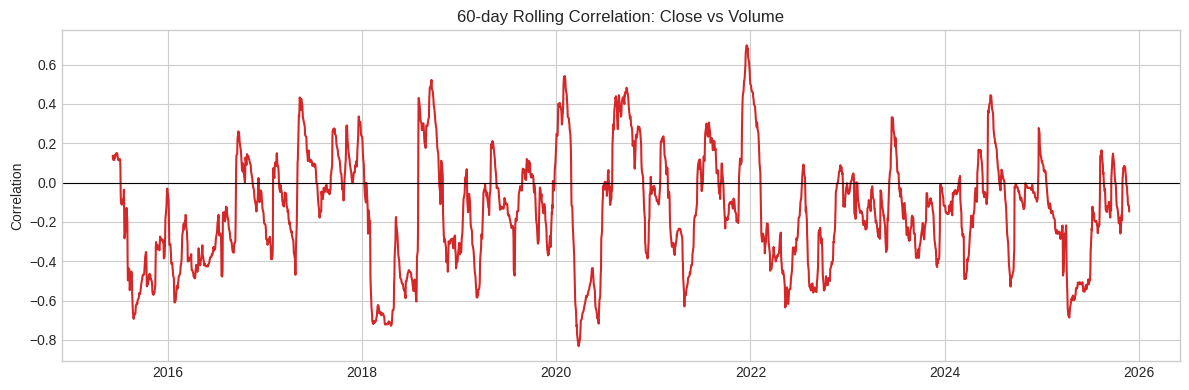

In [108]:
# ************** 7. Rolling correlation between Close and Volume (example) # ************** #
rolling_corr = df_feat['Close'].rolling(window=60).corr(df_feat['Volume'])
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(rolling_corr.index, rolling_corr, color='#d62728')
ax.set_title('60-day Rolling Correlation: Close vs Volume')
ax.set_ylabel('Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'rolling_corr_close_volume.png'), dpi=200)
plt.show()

In [109]:
# ************** 8. Summary statistics table (print and save) # ************** #
summary_stats = corr_features.describe().T
summary_stats['skew'] = corr_features.skew()
summary_stats['kurtosis'] = corr_features.kurtosis()
print("Summary statistics for features:\n", summary_stats[['mean','std','min','25%','50%','75%','max','skew','kurtosis']])

# Save summary to CSV
summary_stats.to_csv(os.path.join(FIG_DIR, 'feature_summary_stats.csv'))

Summary statistics for features:
                      mean           std           min           25%  \
Price                                                                 
Open         1.061580e+02  7.271099e+01  2.052653e+01  3.736214e+01   
High         1.073199e+02  7.350488e+01  2.090741e+01  3.768145e+01   
Low          1.050938e+02  7.200760e+01  2.040566e+01  3.703311e+01   
Close        1.062597e+02  7.279649e+01  2.060408e+01  3.736053e+01   
Volume       1.095747e+08  6.530334e+07  2.323470e+07  6.508660e+07   
Return       1.024046e-03  1.824020e-02 -1.286468e-01 -7.321591e-03   
LogReturn    8.575821e-04  1.822468e-02 -1.377078e-01 -7.348526e-03   
SMA_20       1.054024e+02  7.216635e+01  2.140660e+01  3.740451e+01   
SMA_50       1.040913e+02  7.127981e+01  2.182612e+01  3.742363e+01   
EMA_20       1.054082e+02  7.213182e+01  2.180895e+01  3.734295e+01   
Vol_20       1.648847e-02  7.961531e-03  4.815358e-03  1.140679e-02   
MACD         6.162018e-01  2.334318e+00 -1.

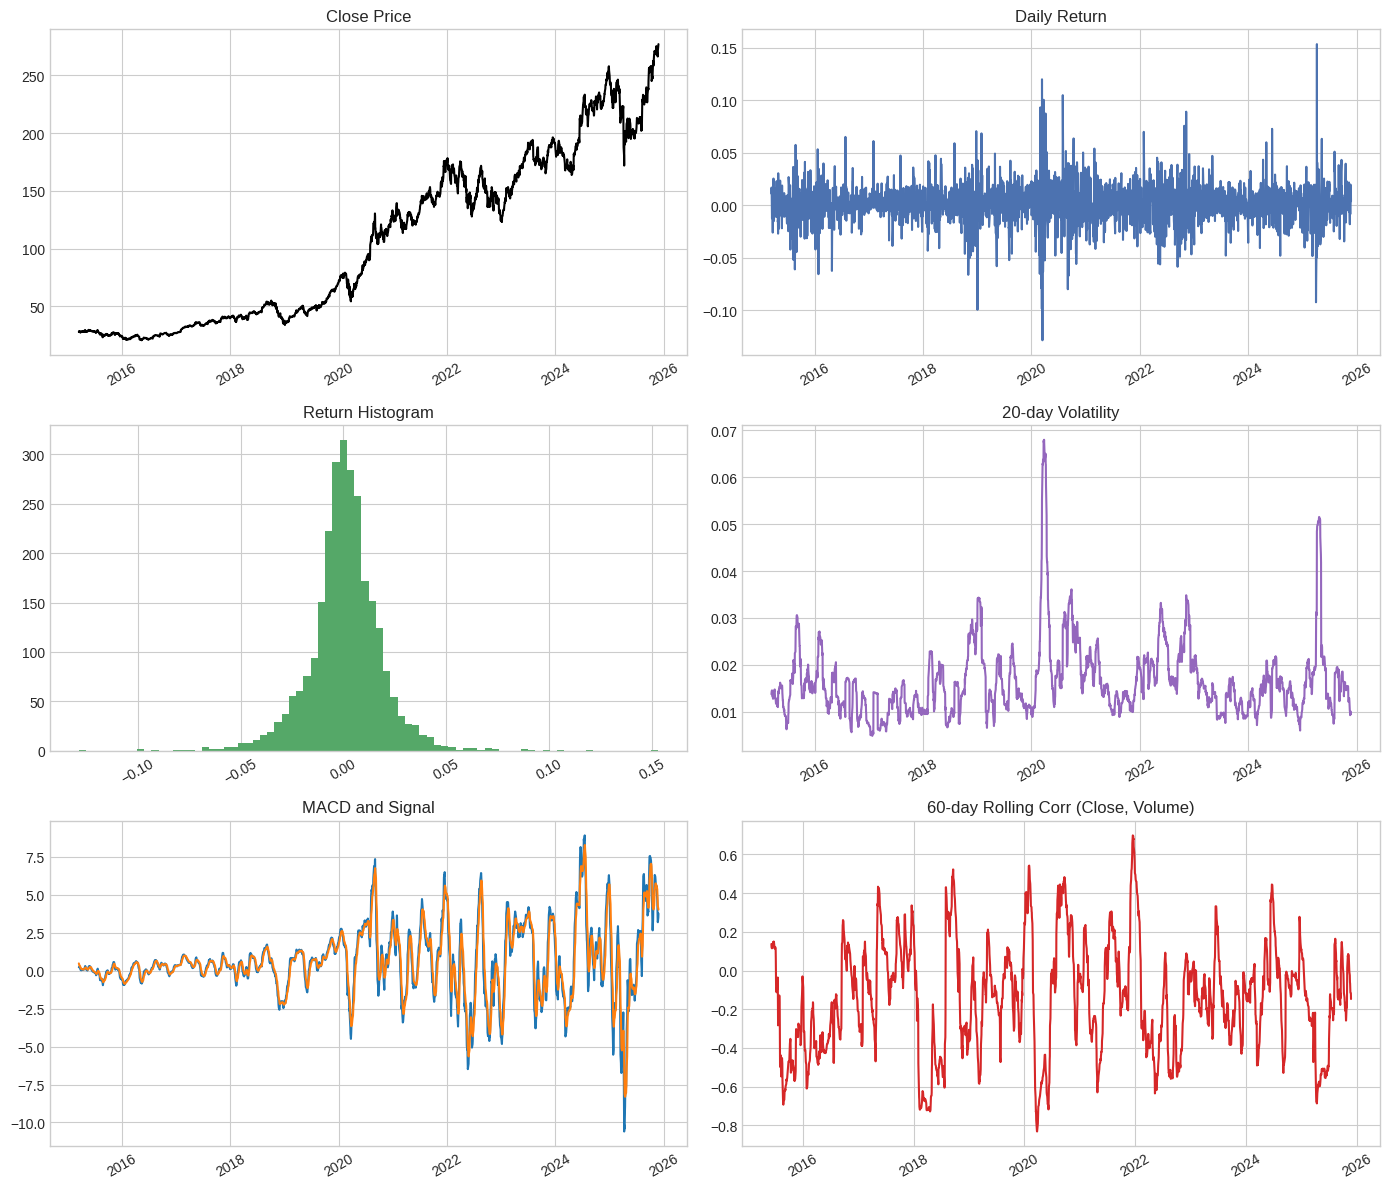

EDA complete. Figures and CSVs saved to eda_figures


In [110]:
# ************** 9. Save a combined figure with multiple subplots for a quick report # ************** #
fig, axes = plt.subplots(3,2, figsize=(14,12))
axes = axes.flatten()
axes[0].plot(df_feat.index, df_feat['Close'], color='black'); axes[0].set_title('Close Price')
axes[1].plot(df_feat.index, df_feat['Return'], color='#4C72B0'); axes[1].set_title('Daily Return')
axes[2].hist(df_feat['Return'].dropna(), bins=80, color='#55A868'); axes[2].set_title('Return Histogram')
axes[3].plot(df_feat.index, df_feat['Vol_20'], color='#9467bd'); axes[3].set_title('20-day Volatility')
axes[4].plot(df_feat.index, df_feat['MACD'], color='#1f77b4'); axes[4].plot(df_feat.index, df_feat['MACD_Signal'], color='#ff7f0e'); axes[4].set_title('MACD and Signal')
axes[5].plot(rolling_corr.index, rolling_corr, color='#d62728'); axes[5].set_title('60-day Rolling Corr (Close, Volume)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'eda_summary_panel.png'), dpi=200)
plt.show()

# 10. Return the feature DataFrame for downstream modeling if needed
# (You can use df_feat to add features to your RNN/LSTM input pipeline)
df_feat.to_csv(os.path.join(FIG_DIR, 'df_features_for_modeling.csv'))
print(f"EDA complete. Figures and CSVs saved to {FIG_DIR}")

In [111]:
# ************** 10. Preprocess and scale # ************** #
scaler = MinMaxScaler()
prices = scaler.fit_transform(df[['Close']].values)

In [112]:
# ************** 11. Create sequences # ************** #
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    X = np.array(X)
    y = np.array(y)
    return X.reshape((X.shape[0], X.shape[1], 1)), y

SEQ_LEN = 60
X, y = create_sequences(prices, seq_len=SEQ_LEN)


In [113]:
# ************** 12. Train/test split (time-series split) # ************** #
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ************** 13. Model builder functions # ************** #
def build_lstm(input_shape, units=50, dropout=0.0):
    model = Sequential([
        LSTM(units, input_shape=input_shape),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_rnn(input_shape, units=50, dropout=0.0):
    model = Sequential([
        SimpleRNN(units, input_shape=input_shape),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [114]:
# ************** 14. Training and evaluation wrapper # ************** #
def train_and_eval(model_builder, X_train, y_train, X_test, y_test, epochs=30, batch_size=32, seed=42):
    set_seed(seed)
    model = model_builder(X_train.shape[1:], units=50, dropout=0.1)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train, validation_split=0.1, epochs=epochs,
                        batch_size=batch_size, callbacks=[es], verbose=0)
    preds = model.predict(X_test).flatten()
    # invert scaling
    preds_inv = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    # metrics
    mse = mean_squared_error(y_test_inv, preds_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, preds_inv)
    mape = np.mean(np.abs((y_test_inv - preds_inv) / y_test_inv)) * 100
    # directional accuracy
    true_dir = np.sign(np.diff(y_test_inv))
    pred_dir = np.sign(np.diff(preds_inv))
    dir_acc = np.mean(true_dir == pred_dir) * 100
    return {'model': model, 'history': history, 'preds': preds_inv, 'y_true': y_test_inv,
            'rmse': rmse, 'mae': mae, 'mape': mape, 'dir_acc': dir_acc}



In [115]:
# ************** 15. Multiple runs to get mean/std # ************** #
def multiple_runs(model_builder, runs=5):
    metrics = {'rmse': [], 'mae': [], 'mape': [], 'dir_acc': []}
    preds_list = []
    for i in range(runs):
        res = train_and_eval(model_builder, X_train, y_train, X_test, y_test, epochs=30, batch_size=32, seed=42+i)
        for k in metrics:
            metrics[k].append(res[k])
        preds_list.append(res['preds'])
    summary = {k: (np.mean(v), np.std(v)) for k,v in metrics.items()}
    return summary, preds_list

lstm_summary, lstm_preds = multiple_runs(build_lstm, runs=3)
rnn_summary, rnn_preds = multiple_runs(build_rnn, runs=3)

print("LSTM summary:", lstm_summary)
print("RNN summary:", rnn_summary)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
LSTM summary: {'rmse': (np.float64(7.647234110695655), np.float64(0.6473224255954996)), 'mae': (np.float64(5.895721842826782), np.float64(0.5512362447289646)), 'mape': (np.float64(2.71115280785666), np.float64(0.24053179693687018)), 'dir_acc': (np.float64(51.24378109452737), np.float64(0.439743023125961))}
RNN summary: {'rmse': (np.float64(6.526260591792361), np.float64(0.6343877051160467)), 'mae': (np.float64(5.1049034739043835), np.float64(0.6390298862865114)), 'mape': (np.float64(2.3278396534568597), np.float64(0.269064611886414)), 'dir_acc': (np.float64(53.35820895522388), np.float64(0.9265960463775728))}


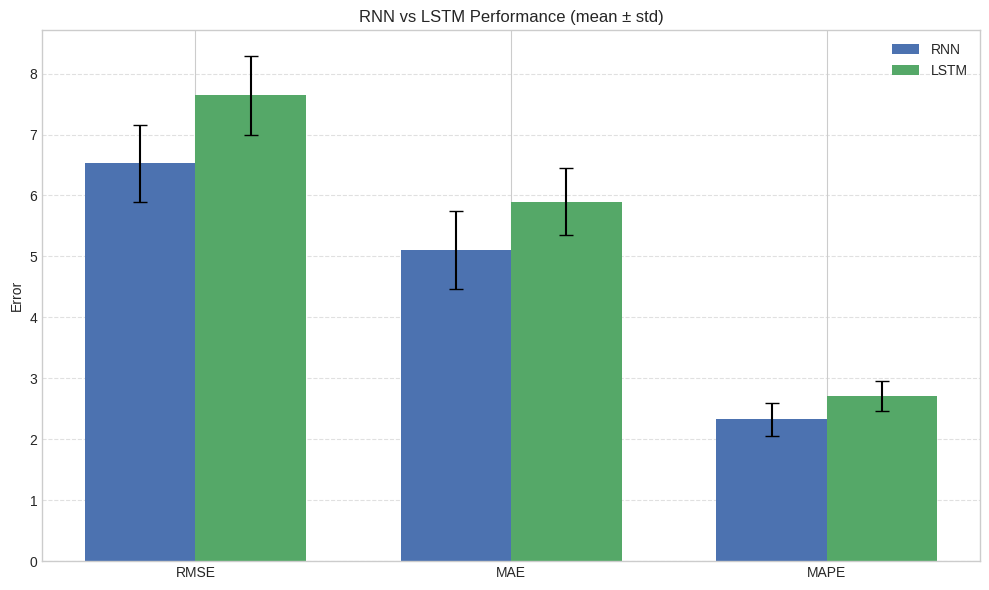

In [116]:
# ************** 16.Plotting comparative bar chart for metrics # ************** #
import matplotlib.pyplot as plt
import numpy as np

# Example: use summaries from previous code
metrics = ['rmse', 'mae', 'mape']
rnn_means = [rnn_summary[m][0] for m in metrics]
rnn_stds  = [rnn_summary[m][1] for m in metrics]
lstm_means = [lstm_summary[m][0] for m in metrics]
lstm_stds  = [lstm_summary[m][1] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, rnn_means, width, yerr=rnn_stds, label='RNN', color='#4C72B0', capsize=5)
ax.bar(x + width/2, lstm_means, width, yerr=lstm_stds, label='LSTM', color='#55A868', capsize=5)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel('Error')
ax.set_title('RNN vs LSTM Performance (mean ± std)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



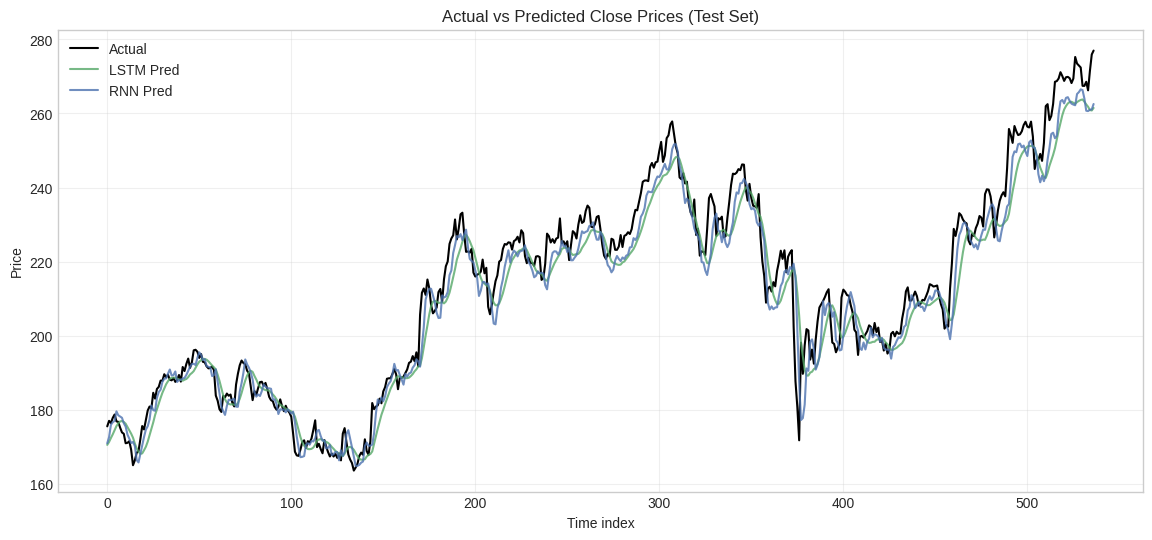

Paired t-test RMSE: t=-1.443, p=0.286


In [117]:
# ************** 17. Time-series plot: actual vs predicted (use last run predictions) # ************** #
idx = np.arange(len(y_test_inv_global))
plt.figure(figsize=(14,6))
plt.plot(idx, y_test_inv_global, label='Actual', color='black')
plt.plot(idx, lstm_preds[-1], label='LSTM Pred', color='#55A868', alpha=0.8)
plt.plot(idx, rnn_preds[-1], label='RNN Pred', color='#4C72B0', alpha=0.8)
plt.legend()
plt.title('Actual vs Predicted Close Prices (Test Set)')
plt.xlabel('Time index')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.show()


from scipy.stats import ttest_rel
rnn_rmse_runs = np.array(rnn_metrics_raw['rmse'])  # list of rmse per run
lstm_rmse_runs = np.array(lstm_metrics_raw['rmse'])
t_stat, p_val = ttest_rel(rnn_rmse_runs, lstm_rmse_runs)
print("Paired t-test RMSE: t=%.3f, p=%.3f" % (t_stat, p_val))